In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import joblib




In [6]:
data_path = 'Data2'

for split in ['train']:
    split_path = os.path.join(data_path, split)
    folders = [name for name in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, name))]
    df_folders = pd.DataFrame({'Nazwa folderu': sorted(folders)})
    df_folders.index += 1

In [7]:

# #Dorzucić przetwarzanie tła

# dataset_path = 'Data2'
# split = 'train'
# split_path = os.path.join(dataset_path, split)

# class_names = sorted([
#     name for name in os.listdir(split_path) 
#     if os.path.isdir(os.path.join(split_path, name))
# ])

# data = []
# labels = []

# for class_name in class_names:
#     class_dir = os.path.join(split_path, class_name)
#     for img_name in os.listdir(class_dir):
#         img_path = os.path.join(class_dir, img_name)
#         img = cv2.imread(img_path)
#         if img is None:
#             continue
#         img = cv2.resize(img, (32, 32))
#         data.append(img)
#         labels.append(class_names.index(class_name))

# X = np.array(data)
# y = np.array(labels)

# X = X.reshape(X.shape[0], -1)

In [8]:
dataset_path = 'Data2'
split = 'train'
split_path = os.path.join(dataset_path, split)

class_names = sorted([
    name for name in os.listdir(split_path) 
    if os.path.isdir(os.path.join(split_path, name))
])

data = []
labels = []

for class_name in class_names:
    class_dir = os.path.join(split_path, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        try:
            img = Image.open(img_path).convert('RGBA')
            background = Image.new('RGBA', img.size, (255, 255, 255, 255))
            background.paste(img, mask=img.split()[3])
            img_rgb = background.convert('RGB')
            img_rgb = img_rgb.resize((32, 32))
            data.append(np.array(img_rgb))
            labels.append(class_names.index(class_name))
        except Exception as e:
            print(f"Pominięto {img_name}: {e}")
            continue

X = np.array(data)
y = np.array(labels)

X = X.reshape(X.shape[0], -1)

Pominięto .DS_Store: cannot identify image file 'Data2/train/Healthy (Mango)/.DS_Store'


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape

(6496, 3072)

In [24]:
X_test.shape

(1624, 3072)

In [25]:
model = SVC(kernel='linear', probability=True)

model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
y_pred=model.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred, target_names=folders))

                                               precision    recall  f1-score   support

                              Healthy (Mango)       0.38      0.53      0.44        59
                        Early blight (Tomato)       0.31      0.30      0.31        67
       Tomato Yellow Leaf Curl Virus (Tomato)       0.25      0.33      0.29        54
                     Bacterial Canker (Mango)       0.37      0.55      0.44        55
                               Healthy (Rice)       0.55      0.42      0.48        57
                Bacterial Leaf Spot (Pumpkin)       0.67      0.52      0.59        65
                         Target Spot (Tomato)       0.82      0.74      0.78        57
                           Gall Midge (Mango)       0.36      0.49      0.41        47
                       Downy Mildew (Pumpkin)       0.41      0.46      0.43        57
                       Powdery Mildew (Mango)       0.29      0.33      0.31        52
                             LeafBlast (Ri

In [29]:
import re

report_dict = classification_report(y_test, y_pred, target_names=sorted(folders), output_dict=True)

rows = []
for class_name, metrics in report_dict.items():
    if class_name in ("accuracy", "macro avg", "weighted avg"):
        continue
    match = re.search(r"\((.+?)\)", class_name)
    plant = match.group(1) if match else "Unknown Disease"
    rows.append({
        "Klasa": class_name,
        "Roslina": plant,
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-score": metrics["f1-score"],
        "Support": int(metrics["support"])
    })

df = pd.DataFrame(rows)

summary = (
    df.groupby("Roslina")
    .agg(
        Precision=("Precision", "mean"),
        Recall=("Recall", "mean"),
        F1_score=("F1-score", "mean"),
        Support=("Support", "sum"),
        Liczba_klas=("Klasa", "count")
    )
    .round(4)
    .sort_values("F1_score", ascending=False)
    .reset_index()
)
summary.index += 1
summary

,Roslina,Precision,Recall,F1_score,Support,Liczba_klas
1,Strawberry,0.7769,0.7574,0.7670,113,2
2,Mango,0.5034,0.4906,0.4922,458,8
3,Tomato,0.4019,0.4087,0.3981,558,10
4,Pumpkin,0.3291,0.3403,0.3277,279,5
5,Rice,0.3466,0.3068,0.3246,216,4


  0%|          | 0/1000 [00:00<?, ?it/s]

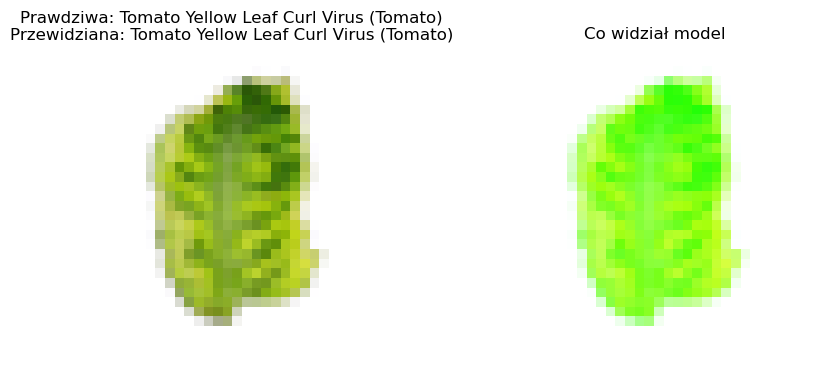

In [30]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    features = images.reshape(len(images), -1)
    return model.predict_proba(features)

def explain_prediction(i):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(X_test[i].reshape(32, 32, 3))
    plt.title(f"Prawdziwa: {class_names[y_test[i]]}\nPrzewidziana: {class_names[model.predict(X_test[i].reshape(1,-1))[0]]}")
    plt.axis('off')
    
    explanation = explainer.explain_instance(
        X_test[i].reshape(32, 32, 3),
        predict_fn,
        top_labels=1,
        num_samples=1000
    )
    
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        num_features=5
    )
    
    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("Co widział model")
    plt.axis('off')
    
    plt.show()

# Użycie:
explain_prediction(0)

  0%|          | 0/1000 [00:00<?, ?it/s]

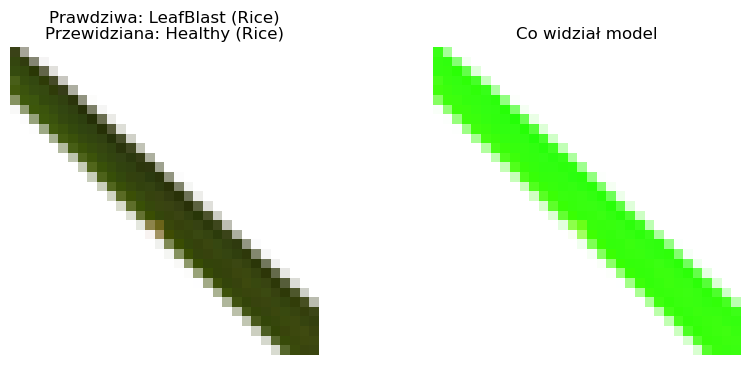

In [42]:
explain_prediction(110)

  0%|          | 0/1000 [00:00<?, ?it/s]

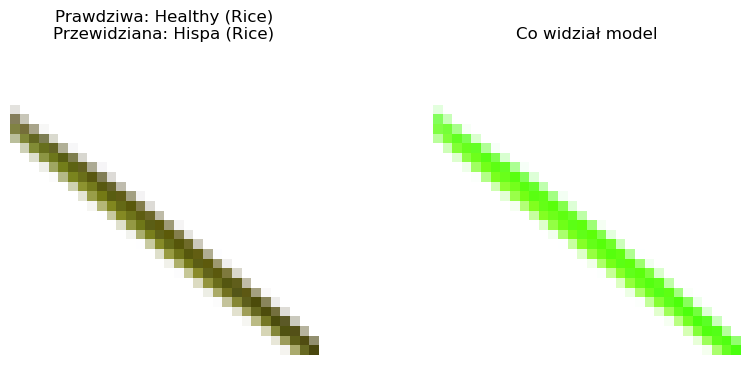

In [18]:
explain_prediction(8)

  0%|          | 0/1000 [00:00<?, ?it/s]

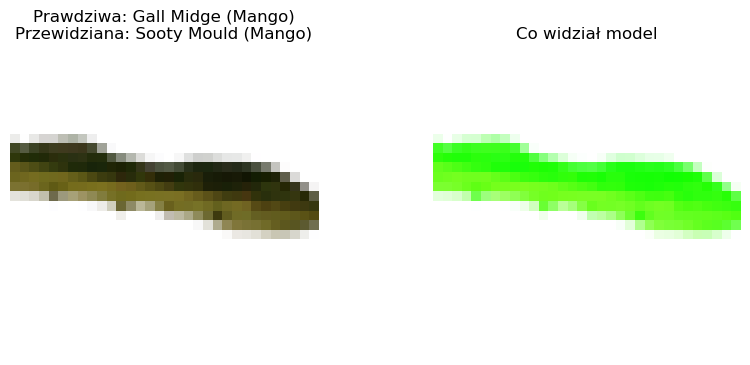

In [35]:
explain_prediction(200)

  0%|          | 0/1000 [00:00<?, ?it/s]

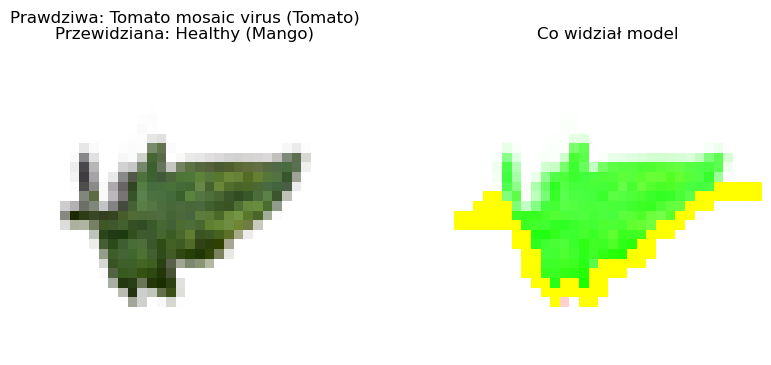

In [38]:
explain_prediction(541)

In [4]:
model = joblib.load('model_asl.pkl')

In [6]:
split_path = os.path.join('Data2', 'train')
class_names = sorted([
    name for name in os.listdir(split_path) 
    if os.path.isdir(os.path.join(split_path, name))
])

joblib.dump({'model': model, 'class_names': class_names}, 'model_asl.pkl')
print(f"Saved {len(class_names)} classes")

Saved 29 classes
